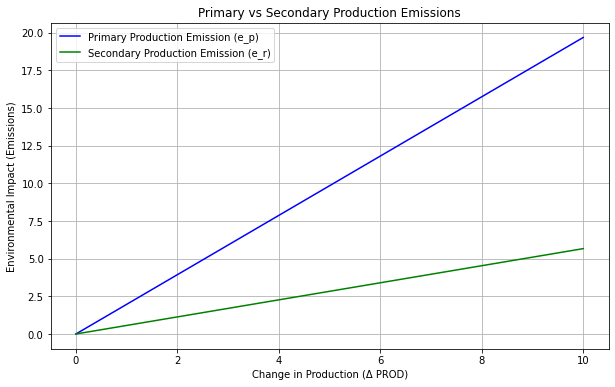

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Set up the parameters
e_r = 0.5664  # Example value for emission from secondary production
e_p = 1.968   # Example value for emission from primary production
Q_r_i = np.linspace(0, 10, 100)  # Original secondary production
Q_r_f = np.linspace(0, 10, 100)  # Final secondary production
Q_p_i = np.linspace(0, 10, 100) # Original primary production
Q_p_f = np.linspace(0, 10, 100) # Final primary production

# Calculate emissions for primary and secondary production
emission_primary_i = e_p * Q_p_i # Initial primary production emission
emission_primary_f = e_p * Q_p_f # Final primary production emission
emission_secondary_f = e_r * Q_r_f # Secondary production emission


# Plot the graph
plt.figure(figsize=(10, 6))
plt.plot(Q_p_f, emission_primary_f, label='Primary Production Emission (e_p)', color='blue')
plt.plot(Q_r_f, emission_secondary_f, label='Secondary Production Emission (e_r)', color='green')


# Labels and title
plt.xlabel('Change in Production (Δ PROD)')
plt.ylabel('Environmental Impact (Emissions)')
plt.title('Primary vs Secondary Production Emissions')
plt.legend()
plt.grid(True)
plt.show()


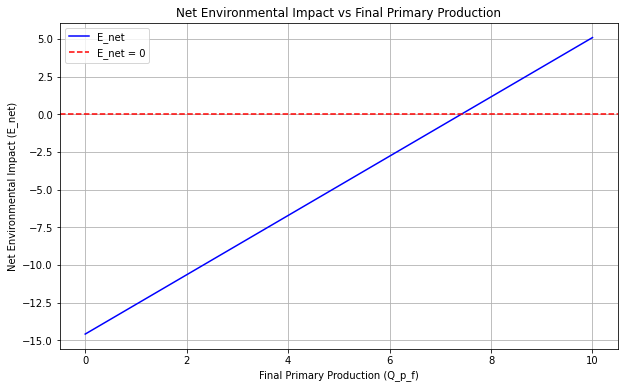

The optimal primary production point where E_net = 0 occurs at Q_p_f = 7.37


In [23]:
import numpy as np
import matplotlib.pyplot as plt

def find_optimal_primary_production(e_r, e_p, Q_r_i, Q_p_i, Q_r_f, Q_p_f_range):
    """
    Calculate and plot the net environmental impact E_net and find the optimal primary production
    point where E_net = 0.

    Parameters:
    - e_r: Emission from secondary production.
    - e_p: Emission from primary production.
    - Q_r_i: Initial secondary production.
    - Q_p_i: Initial primary production.
    - Q_r_f: Final secondary production (fixed value).
    - Q_p_f_range: Range of final primary production values (numpy array).

    Returns:
    - optimal_primary_production: The value of Q_p_f where E_net = 0 (if found).
    """

    # Calculate the change in production
    delta_Q_r = Q_r_f - Q_r_i  # Change in secondary production (fixed)
    delta_Q_p = Q_p_f_range - Q_p_i  # Change in primary production

    # Calculate E_net
    E_net = e_r * delta_Q_r + e_p * delta_Q_p

    # Plot the graph
    plt.figure(figsize=(10, 6))
    plt.plot(Q_p_f_range, E_net, label='E_net', color='blue')

    # Plot the zero line (intersection point)
    plt.axhline(0, color='red', linestyle='--', label='E_net = 0')

    # Labels and title
    plt.xlabel('Final Primary Production (Q_p_f)')
    plt.ylabel('Net Environmental Impact (E_net)')
    plt.title('Net Environmental Impact vs Final Primary Production')
    plt.legend()
    plt.grid(True)

    # Show the plot
    plt.show()

    # Find the intersection point where E_net is zero
    intersection_index = np.where(np.diff(np.sign(E_net)))[0]
    if intersection_index.size > 0:
        optimal_primary_production = Q_p_f_range[intersection_index][0]
        print(f'The optimal primary production point where E_net = 0 occurs at Q_p_f = {optimal_primary_production:.2f}')
        return optimal_primary_production
    else:
        print("No intersection point where E_net = 0 found.")
        return None

# Example usage of the function
optimal_primary_production = find_optimal_primary_production(
    e_r=0.5664,
    e_p=1.968,
    Q_r_i=0,
    Q_p_i=10,
    Q_r_f=9,  # Example fixed final secondary production, should be smaller than Q_p_i
    Q_p_f_range=np.linspace(0, 10, 100)  # Range of final primary production
)


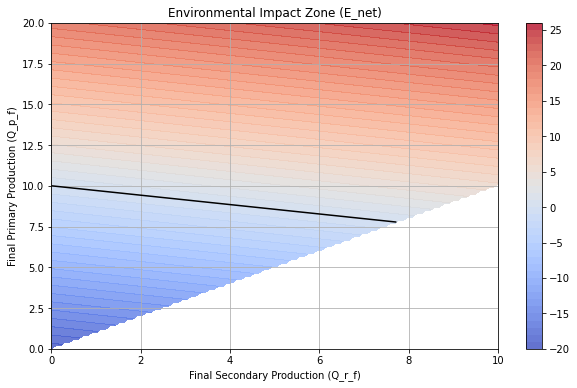

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def plot_environmental_impact_zone(e_r, e_p, Q_r_i, Q_p_i, Q_r_f_range, Q_p_f_range):
    """
    Plot the environmental impact zone where E_net >= 0, ensuring Q_r_f <= Q_p_f.

    Parameters:
    - e_r: Emission from secondary production.
    - e_p: Emission from primary production.
    - Q_r_i: Initial secondary production.
    - Q_p_i: Initial primary production.
    - Q_r_f_range: Range of final secondary production values (numpy array).
    - Q_p_f_range: Range of final primary production values (numpy array).
    """

    # Create a grid of Q_r_f and Q_p_f values
    Q_r_f, Q_p_f = np.meshgrid(Q_r_f_range, Q_p_f_range)

    # Apply the condition: Q_r_f <= Q_p_f
    mask = Q_r_f <= Q_p_f

    # Calculate the change in production
    delta_Q_r = Q_r_f - Q_r_i  # Change in secondary production
    delta_Q_p = Q_p_f - Q_p_i  # Change in primary production

    # Calculate E_net, masking out invalid regions where Q_r_f > Q_p_f
    E_net = np.where(mask, e_r * delta_Q_r + e_p * delta_Q_p, np.nan)

    # Plotting the contour and the region where E_net >= 0
    plt.figure(figsize=(10, 6))
    cp = plt.contourf(Q_r_f, Q_p_f, E_net, levels=50, cmap='coolwarm', alpha=0.8)
    plt.colorbar(cp)

    # Highlight the region where E_net >= 0
    plt.contour(Q_r_f, Q_p_f, E_net, levels=[0], colors='black', linewidths=1.5)

    # Labels and title
    plt.xlabel('Final Secondary Production (Q_r_f)')
    plt.ylabel('Final Primary Production (Q_p_f)')
    plt.title('Environmental Impact Zone (E_net)')
    plt.grid(True)
    
    plt.show()

# Example usage of the function
Q_r_f_range = np.linspace(0, 10, 100)  # Range of final secondary production
Q_p_f_range = np.linspace(0, 20, 100)  # Range of final primary production

plot_environmental_impact_zone(
    e_r=0.5664,
    e_p=1.968,
    Q_r_i=0,
    Q_p_i=10,
    Q_r_f_range=Q_r_f_range,
    Q_p_f_range=Q_p_f_range
)
